# MOwNiT 
## Laboratorium
### Znajdowanie pierwiastków

Do poszukiwania pierwiastków funkcji w Julii używamy pakietu Roots

```julia
Pkg.add("Roots")
Pkg.add("ForwardDiff")
```

In [121]:
using Pkg
Pkg.add("Roots")
Pkg.add("ForwardDiff")
Pkg.add("Plots")
Pkg.add("DataFrames")
Pkg.add("Measures")
Pkg.add("CSV")
Pkg.add("Statictics")
Pkg.add("LinearAlgebra")
using Roots  
using Plots
using ForwardDiff

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
    Updating `~/.julia/environments/v1.10/Project.toml`
  [336ed68f] + CSV v0.10.16
    Updating `~/.julia/environments/v1.10/Manifest.toml`
  [336ed68f] + CSV v0.10.16
  [48062228] + FilePathsBase v0.9.24
 

LoadError: The following package names could not be resolved:
 * Statictics (not found in project, manifest or registry)
[36m   Suggestions:[39m [0m[1mS[22m[0m[1mt[22m[0m[1ma[22m[0m[1mt[22m[0m[1mi[22m[0m[1mc[22m[0m[1mT[22mraff[0m[1mi[22m[0m[1mc[22mA[0m[1ms[22msignment LengthFree[0m[1mS[22m[0m[1mt[22m[0m[1ma[22m[0m[1mt[22m[0m[1mi[22m[0m[1mc[22mMa[0m[1mt[22mr[0m[1mi[22m[0m[1mc[22me[0m[1ms[22m [0m[1mS[22m[0m[1mt[22m[0m[1ma[22m[0m[1mt[22m[0m[1mi[22m[0m[1mc[22m[0m[1mT[22mh[0m[1mi[22mngs

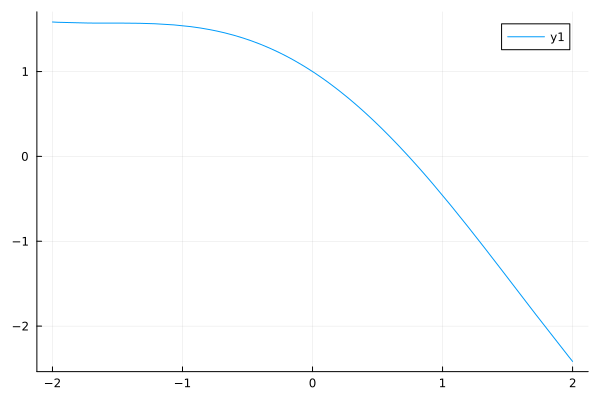

In [122]:
# przykładowa funkcja do testów
f(x) = cos(x) - x
plot(f, -2, 2)

Funkcja <i> find_zero</i>  dobiera odpowiedni algorytm w zależności od sposobu wywołania.


### 1. Metody wykorzytujące  przedział i zmianę znaku

#### 1.1 Metoda bisekcji - jesli wywołamy fzero z podaniem  przedziału (tutaj (0,1))

In [123]:
x = find_zero(f, (0, 1),verbose=true)  

0.7390851332151607

In [124]:
# mozna wyspecyfikowac wprost
x = find_zero(f, (0, 1), Bisection(),verbose=true)  

0.7390851332151607

#### Sprawdzanie, czy znaleźliśmy 0

In [125]:
#Sprawdzamy czy znaleźliśmy 0
iszero(f(x))

true

In [126]:
# można też sprawdzić, czy funkcja zmienia znak dla lewego i prawego sąsiada miejsca zerowego.
sign(f(prevfloat(x))) *sign(f(nextfloat(x))) 

-1.0

In [127]:
# czasem algorytm znajduje najlepsze przybliżenie 0
g(x) = sin(x)
x = find_zero(g, (pi/2, 3pi/2))
x, g(x)

(3.141592653589793, 1.2246467991473532e-16)

In [128]:
# nie jest to dokładnie 0, ale ...
iszero(g(x))

false

In [129]:
#... najbliższy lewy albo prawy sąsiad leży po przeciwnej stronie osi x  niż nasze 0.
g(prevfloat(x)) * g(x) < 0.0 || g(x) * g(nextfloat(x)) < 0.0

true

#### 1.2 Metoda regula falsi

In [130]:
find_zero(f, (0, 1), FalsePosition(), verbose=true) 

0.7390851332151607

In [131]:
# do dyspozycji mamy  12 wersji algorytmu regula falsi
find_zero(f, (0, 1), FalsePosition(12), verbose=true)

0.7390851332151607

### 2. Metody korzystające z pochodnych

#### 2.1 Metoda Newtona, potrzebuje punktu startowego i wykorzystuje pochodną funkcji.

Aby użyć Metody Newtona, można skorzystać z pakietu ForwardDiff, aby obliczyć pochodną funkcji. 

In [132]:
# definujemy D(f) obliczającą  funkcje pochodną 
D(f) = x->ForwardDiff.derivative(f, float(x))

D (generic function with 1 method)

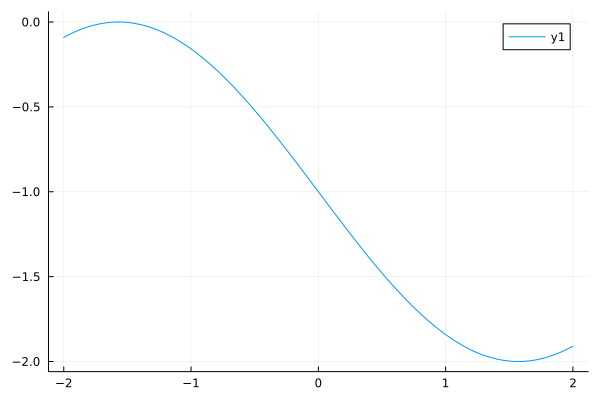

In [133]:
plot(D(f), -2,2)

In [134]:
#wywolanie metody Newtona
find_zero((f, D(f)),0, Roots.Newton(),verbose=true)

0.7390851332151607

#### 2.2 Metoda Halleya (potrzebuje pierwszej i drugiej pochodnej)

In [135]:
DD(f) = x->ForwardDiff.derivative(D(f), float(x))
find_zero((f, D(f), DD(f)), 0.0, Roots.Halley(), verbose=true) 

0.7390851332151606

### 3. Metody korzystające z przybliżenia pochodnej

#### 3.1 Domyślna metoda bazuje na metodzie z <a href="http://www.hpl.hp.com/hpjournal/pdfs/IssuePDFs/1979-12.pdf"> kalkulatorów HP-34</a> , używa metody siecznych
oraz metody bazującej na przedziale wg artykułu:

<a href="http://na.math.kit.edu/alefeld/download/1995_Algorithm_748_Enclosing_Zeros_of_Continuous_Functions.pdf">G. E. Alefeld, F. A. Potra, and
Y. Shi, "Algorithm 748: enclosing zeros of continuous functions," ACM
Trans. Math. Softw. 21, 327–344 (1995), DOI: 10.1145/210089.210111. </a>

In [136]:
x = find_zero(f, 0,   verbose=true)

0.7390851332151607

Metody find_zero dla wyzszych rzędów to wariacje metody Newtona, które nie korzystaja z pochodnej, ale ja przyblizają.


#### 3.2 Metoda siecznych

In [137]:
# wywołanie find_zero używając punktu startowego (a nie przedziału) 
# oraz opcji order=1   wykorzystuje metodę siecznych  
x = find_zero(f, 0, Order1(),  verbose=true) 

0.7390851332151607

In [138]:
# metoda siecznych może być wywołana bezpośrednio 
# implementacja taka sama jak find_zero(f, 0, Order1()), ale bez
# narzutów frameworku oraz mniejsza ilość sprawdzanych warunków zbieżności - szybsza
Roots.secant_method(f, 0)

0.7390851332151607

In [139]:
# mozemy podać przedział
Roots.secant_method(f, (0,1))

0.7390851332151607

#### 3.3 Metoda Steffensena 
przybliża pochodną poprzez  (f(x + f(x)) - f(x))/f(x)  
aby ja wywołać podajemy punkt startowy oraz order 2

In [140]:
x = find_zero(f, 0, Order2(), verbose=true) 

0.7390851332151607

In [141]:
# mozliwe sa jeszcze rzędy 5, 8 i 16
x = find_zero(f, 0, Order8(), verbose=true) 

0.7390851332151607

Można użyć funkcji fzero do znajdowania nieciagłości

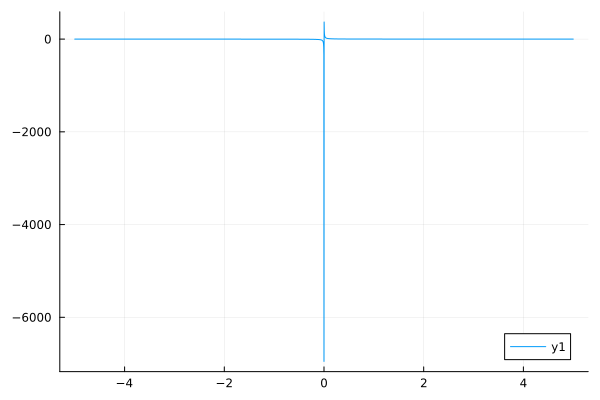

In [142]:
plot(x -> 1/x)

In [143]:
find_zero(x -> 1/x, (-1, 1), verbose=true)

0.0

find_zeros - szukanie więcej niż jednego pierwiastka. Wykorzystuje podział przedziału na mniejsze podprzedziały

In [144]:
find_zeros(x ->(x-3)*x, -10, 10)

2-element Vector{Float64}:
 0.0
 3.0

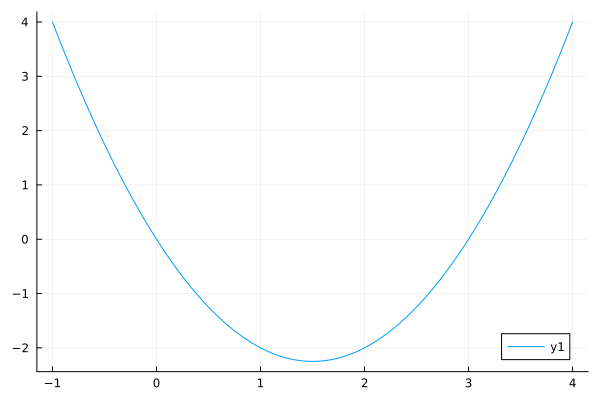

In [145]:
plot(x ->(x-3)*x,-1,4)

Więcej na https://docs.juliahub.com/Roots/o0Xsi/2.2.5/

### 4. Wyciąganie informacji z przebiegu działania funkcji: 

https://docs.juliahub.com/Roots/o0Xsi/2.2.5/reference/#Roots.Tracks 

In [146]:
tracker = Roots.Tracks()

Algorithm has not been run

In [147]:
find_zero(f, (0, 2), Roots.Secant(), tracks=tracker)

0.7390851332151607

In [148]:
tracker

Results of univariate zero finding:

* Converged to: 0.7390851332151607
* Algorithm: Secant()
* iterations: 7
* function evaluations ≈ 9
* stopped as f(x_n) = 0

Trace:
x₁ =  0                   	 fx₁ =  1                  
x₂ =  2                   	 fx₂ = -2.4161468365471426 
x₃ =  0.58545492793321863 	 fx₃ =  0.24800586076647069
x₄ =  0.7171348682551959  	 fx₄ =  0.036556996479681581
x₅ =  0.73990076549012351 	 fx₅ = -0.0013652977662494958
x₆ =  0.73908113605420545 	 fx₆ =  6.6896907529034877e-06
x₇ =  0.73908513249559438 	 fx₇ =  1.2042747910001594e-09
x₈ =  0.73908513321516134 	 fx₈ = -1.1102230246251565e-15
x₉ =  0.73908513321516067 	 fx₉ =  0                  


In [149]:
tracker.steps

7

In [150]:
 tracker.fncalls

9

<b>WAŻNE: empty!(tracker) po każdym wywołaniu funkcji, inaczej zostają tam wyniki z poprzednich wywołań zakłamujące dane.</b>

### Zadanie:

A. Wybrać trzy metody poszukiwania pierwiastków: 

* wykorzystującą przedział i zmianę znaku, 
* wykorzystującą pochodną, 
* wykorzystującą przybliżenie pochodnej

    1. Każdą z trzech wybranych metod przetestować (ilość iteracji, ilość wywołań funkcji) na sześciu wybranych  funkcjach ze zbioru http://people.sc.fsu.edu/~jburkardt/py_src/test_zero/test_zero.html Wyniki przedstawić w formie tabelki. <b>Pamiętać o sprawdzeniu czy wynik jest poprawny poprzez obliczenie wartości funkcji dla znalezionego pierwiastka !</b> (3 pkt)

    2. Zademonstrować wybrany, ciekawy przykład trudnej funkcji z p.1 i działania metod na niej. (1 pkt)

    3. Dla każdej z wybranych metod zademonstrować i wyjaśnić po jednym  przykładzie, dla którego nie działają (można na podstawie p.1 lub wymyślić własny)(1 pkt)

B. Narysować <a href="https://pl.wikipedia.org/wiki/Wst%C4%99ga_Newtona"> wstegę Newtona </a> i objaśnić, w jaki sposób powstała i jaki jest jej związek z metodą Newtona do znajdowania pierwiastków. Sposób i język - dowolny. (1 pkt)

In [151]:
Pkg.add("Symbolics")
using Roots,Plots,ForwardDiff,LinearAlgebra,Statistics,Measures,DataFrames,CSV,Symbolics

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


## 1. Porównanie metod poszukiwania pierwiastków

In [216]:
tests = Function[]
example(x) = sin(x) - x/2
example2(x) = cos(x) - x
example3(x) = (x+3)*(x-1)^2
example4(x) =  20.0*x/(100.0*x*x + 1.0)
example5(x) =  x*exp(-x)
example6(x) = 2*x-exp(-x)
push!(tests,example)
push!(tests,example2)
push!(tests,example3)
push!(tests,example4)
push!(tests,example5)
push!(tests,example6)
df = DataFrame(What=Function[],How=Function[],Iters=Float64[],Calls=Float64[])
# tracker w celu sprawdzenia ilości iteracji i ilości wywołań funkcji
tracker_bis = Roots.Tracks()
# korzystam ze wzrou z konspektu
bisection(f) = find_zero(f, (-10, 5), Bisection(), tracks = tracker_bis) 
# definujemy D(f) obliczającą  funkcje pochodną 
D(f) = x->ForwardDiff.derivative(f, float(x))
# korzystam ze wzrou z konspektu
tracker_newt = Roots.Tracks()
newtonMethod(f) = find_zero((f, D(f)),0, Roots.Newton(),tracks = tracker_newt)
# korzystam ze wzrou z konspektu
tracker_ste = Roots.Tracks()
steffensen(f) = find_zero(f, 0.0, Order2(),tracks = tracker_ste)
for test in tests
    # Bisection - dwa punky f(x1) < 0 i f(x2) > 0 korzysta z twierdzenia darboux
    res1 = bisection(test)
    if test(res1) != 0
        println("Error ocured ",test," ", bisection," ", test(res1))
    end
    push!(df,(test,bisection,tracker_bis.steps,tracker_bis.fncalls))
    empty!(tracker_bis)

    # Newton - przechodzi do miejsca + f(x)/f`(x)
    res2 = newtonMethod(test)
    if test(res2) != 0
        println("Error ocured ",test," ", newtonMethod," ", test(res2))
    end
    push!(df,(test,newtonMethod,tracker_newt.steps, tracker_newt.fncalls))
    empty!(tracker_newt)

    # Steffensen - przyblizenia pochodnych - korzysta z ilorazu roznicowego
    res3 = steffensen(test)
    if test(res3) != 0
        println("Error ocured ",test," ", steffenson," ", test(res3))
    end
    push!(df,(test,steffensen,tracker_ste.steps, tracker_ste.fncalls))
    empty!(tracker_ste)
end
df

# 0 maszynowe

Error ocured example3 newtonMethod 4.564959859473074e-16
Error ocured example4 steffenson -1.3068505686305758e-8
Error ocured example6 newtonMethod -1.1102230246251565e-16


Row,What,How,Iters,Calls
,Function,Function,Float64,Float64
1,example,bisection,0.0,3.0
2,example,newtonMethod,1.0,2.0
3,example,steffensen,6.0,10.0
4,example2,bisection,62.0,65.0
5,example2,newtonMethod,5.0,10.0
6,example2,steffensen,7.0,11.0
7,example3,bisection,59.0,62.0
8,example3,newtonMethod,26.0,52.0
9,example3,steffensen,0.0,2.0


## 2. Przykład trudnej funkcji

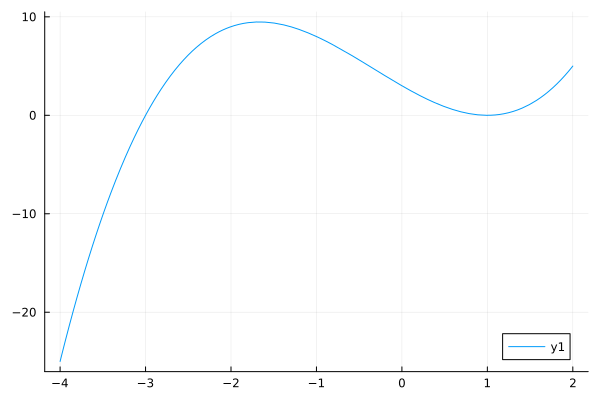

In [217]:
g(x) = (x+3)*(x-1)^2
xs = -4:2
plot(g, extrema(xs)...)

In [242]:
table = DataFrame(How=Function[],Iters=Float64[],Calls=Float64[])

tracker_bis = Roots.Tracks()
# korzystam ze wzrou z konspektu
bisection(f) = find_zero(f, (-4, 2), Bisection(), tracks = tracker_bis) 
# definujemy D(f) obliczającą  funkcje pochodną 
D(f) = x->ForwardDiff.derivative(f, float(x))
# korzystam ze wzrou z konspektu
tracker_newt = Roots.Tracks()
newtonMethod(f) = find_zero((f, D(f)), 2.0, Roots.Newton(),tracks = tracker_newt)

# korzystam ze wzrou z konspektu
tracker_ste = Roots.Tracks()
steffensen(f) = find_zero(f, 2.0, Order2(),tracks = tracker_ste)

# bis
bisection(g)
push!(table,(bisection, tracker_bis.steps, tracker_bis.fncalls))
# newt
newtonMethod(g)
push!(table,(newtonMethod,tracker_newt.steps, tracker_newt.fncalls))
# stef

steffensen(g)
println(bisection(g))
println(steffenson(g))
push!(table,(steffenson, tracker_ste.steps, tracker_ste.fncalls))


-3.0
1.0000000122006383


Row,How,Iters,Calls
,Function,Float64,Float64
1,bisection,61.0,64.0
2,newtonMethod,27.0,54.0
3,steffenson,58.0,102.0


## 3. Przykłady funkcji dla których metody dają błędne wyniki

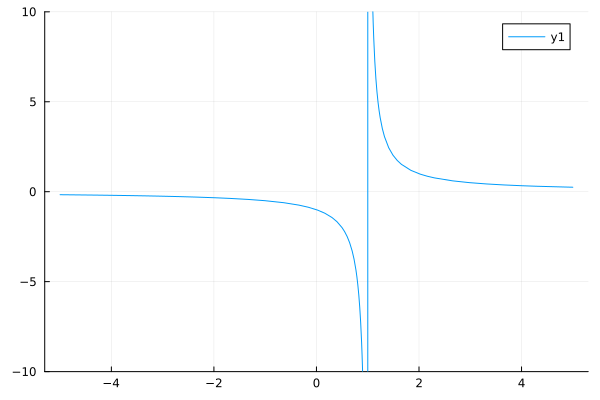

In [243]:
using Plots

f(x) = x/(x-1) - 1
xs = -1:2
plot(f, ylim = (-10,10))

In [244]:
# funkcja nie jest ciągła na podanym przedziale, i nie ma miejsca zerowego
res = find_zero(f,(-1,1),Bisection())
f(res)
# Metoda bisekcji zakłada, że:
# 1. Funkcja jest ciągła na zadanym przedziale [a, b].
# 2. Funkcja zmienia znak na końcach przedziału, czyli f(a) * f(b) < 0.
# Tylko wtedy gwarantowane jest istnienie pierwiastka w przedziale (twierdzenie Darboux).

-9.007199254740992e15

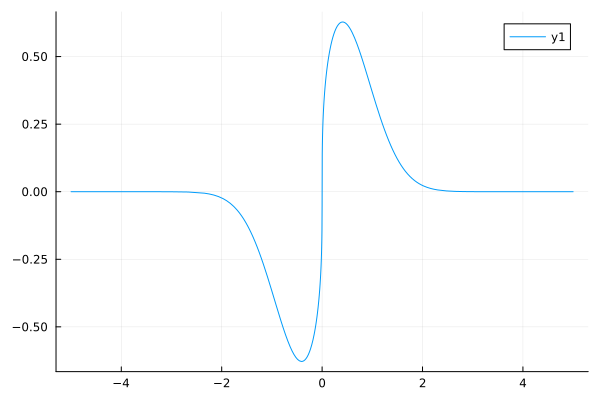

In [245]:
function newtonPatology(x)
    if x < 0.0
        fx = -abs(x)^(1.0/3.0)*exp(-x^2)
    elseif x == 0.0
        fx = 0.0
    else
        fx = abs(x)^(1.0/3.0)*exp(-x^2)
    end
    return fx
end
plot(newtonPatology)

In [246]:
newtonMethod(newtonPatology)
# Metoda Newtona zakłada, że:
# 1. Funkcja jest różniczkowalna w pobliżu pierwiastka.
# 2. Pochodna funkcji w tym punkcie nie jest bliska zeru ani nieskończoności.
# W tym przypadku funkcja newtonPatology ma bardzo strome (niemal pionowe) pochodne w pobliżu zera,
# co powoduje niestabilność metody i błędne przybliżenia.

5.824640932271383

In [247]:
res3 = steffensen(newtonPatology)
println(res3)

# Metoda Steffensena, podobnie jak Newtona, zakłada że funkcja jest ciągła i gładka (różniczkowalna)
# w pobliżu miejsca zerowego.

5.858398054826021


## Zadanie 2. Wstęga Newtona

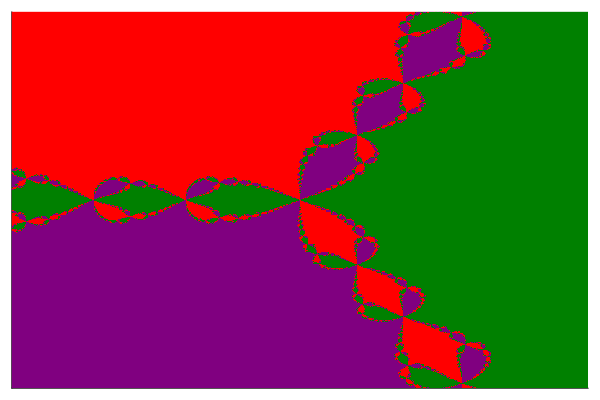

In [189]:
z(x) = x^3 - 1
function get_map(z)
    @variables x
    Dx = Differential(x)
    map = x - z(x) / Dx(z(x)) |> expand_derivatives
    update_expr = build_function(map, x)
    return eval(update_expr)
end
function applyiteratively(x, update; n=100)
    for i in 1:n
        x = update(x)
    end
    return x
end
update = get_map(z)
lower = -2 - 2im
upper = 2 + 2im
stepp = 0.5e-2
Z0 = [a+b*im for b in real(lower):stepp:real(upper),
                    a in imag(lower):stepp:imag(upper)]
Z100 = applyiteratively.(Z0, update)
heatmap(angle.(Z100), colorbar=false, color=:rainbow, ticks=false)
# Metoda Newtona korzysta z pochodnej, aby „krok po kroku” zbliżać się do pierwiastka.
# Jednak w miejscach, gdzie pochodna jest mała lub zmienia się gwałtownie, iteracje mogą „odskoczyć” daleko,
# przez co trajektoria może skręcać i ostatecznie trafić do innego pierwiastka lub w niestabilne obszary.